# CodeAlpha Data Analytics Internship — Task 3
## Data Visualization
### Project: Restaurant Reviews Dataset

This notebook covers Task 3 of the CodeAlpha Data Analytics internship: transforming
the cleaned restaurant reviews dataset into clear, decision-supporting charts and
visual stories.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Load & Clean the Data

In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/restaurant_reviews.csv")
print("Raw shape:", df.shape)
df.head()


Raw shape: (658, 8)


,review_id,restaurant_name,cuisine_type,city,rating,review_text,review_length,review_date
0,1,The Burger Joint,American,Bengaluru,5,"Fresh ingredients and bold flavors, highly rec...",121,2025-05-15
1,2,Green Leaf Cafe,Vegan,Mumbai,3,"Reasonable prices, the menu could use more var...",58,2023-07-29
2,3,Smoky BBQ Pit,American,Mumbai,4,The food was absolutely delicious and beautifu...,108,2024-12-05
3,4,Coastal Kitchen,Seafood,Chennai,4,"Great spot for a family dinner, kids loved it ...",107,2023-06-11
4,5,Rustic Oven,Italian,Bengaluru,4,The food was absolutely delicious and beautifu...,60,2024-01-29


In [3]:
# Data cleaning
df_clean = df.copy()
df_clean["rating"] = pd.to_numeric(df_clean["rating"], errors="coerce")
df_clean = df_clean.drop_duplicates()
df_clean = df_clean[df_clean["review_text"].notna() & (df_clean["review_text"].str.strip() != "")]
df_clean["city"] = df_clean["city"].fillna("Unknown")
df_clean["review_date"] = pd.to_datetime(df_clean["review_date"])
df_clean = df_clean.dropna(subset=["rating"])
df_clean["rating"] = df_clean["rating"].astype(int)

print("Cleaned shape:", df_clean.shape)
df_clean.head()


Cleaned shape: (645, 8)


,review_id,restaurant_name,cuisine_type,city,rating,review_text,review_length,review_date
0,1,The Burger Joint,American,Bengaluru,5,"Fresh ingredients and bold flavors, highly rec...",121,2025-05-15
1,2,Green Leaf Cafe,Vegan,Mumbai,3,"Reasonable prices, the menu could use more var...",58,2023-07-29
2,3,Smoky BBQ Pit,American,Mumbai,4,The food was absolutely delicious and beautifu...,108,2024-12-05
3,4,Coastal Kitchen,Seafood,Chennai,4,"Great spot for a family dinner, kids loved it ...",107,2023-06-11
4,5,Rustic Oven,Italian,Bengaluru,4,The food was absolutely delicious and beautifu...,60,2024-01-29


## 2. Visualization 1 — Rating Distribution

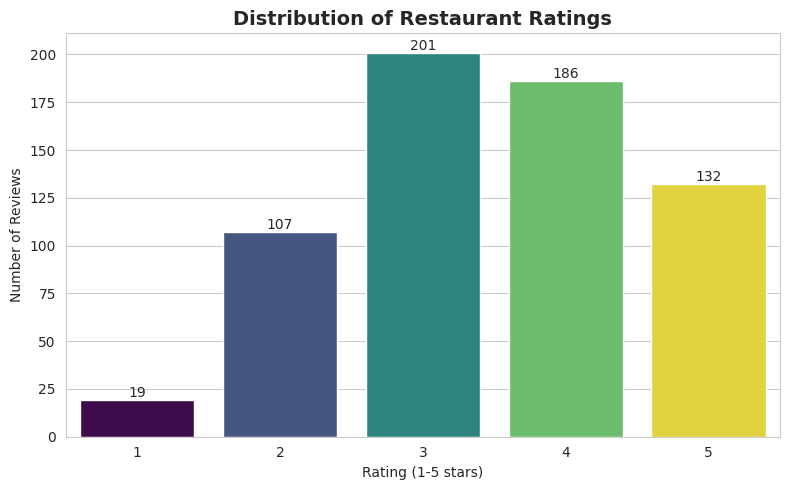

In [4]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df_clean, x='rating', hue='rating', palette='viridis', legend=False)
ax.set_title('Distribution of Restaurant Ratings', fontsize=14, fontweight='bold')
ax.set_xlabel('Rating (1-5 stars)')
ax.set_ylabel('Number of Reviews')
for container in ax.containers:
    ax.bar_label(container)
plt.tight_layout()
plt.savefig('../charts/01_rating_distribution.png', dpi=150)
plt.show()

## 3. Visualization 2 — Average Rating by Cuisine

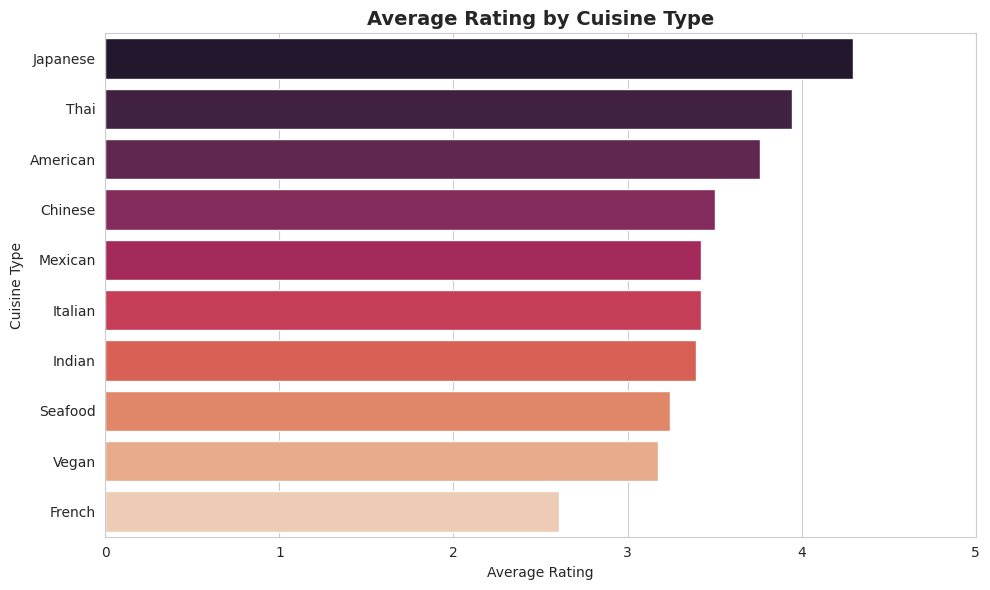

In [5]:
plt.figure(figsize=(10, 6))
cuisine_sorted = df_clean.groupby('cuisine_type')['rating'].mean().sort_values(ascending=False)
ax = sns.barplot(x=cuisine_sorted.values, y=cuisine_sorted.index, hue=cuisine_sorted.index, palette='rocket', legend=False)
ax.set_title('Average Rating by Cuisine Type', fontsize=14, fontweight='bold')
ax.set_xlabel('Average Rating')
ax.set_ylabel('Cuisine Type')
ax.set_xlim(0, 5)
plt.tight_layout()
plt.savefig('../charts/02_avg_rating_by_cuisine.png', dpi=150)
plt.show()

## 4. Visualization 3 — Review Volume Over Time

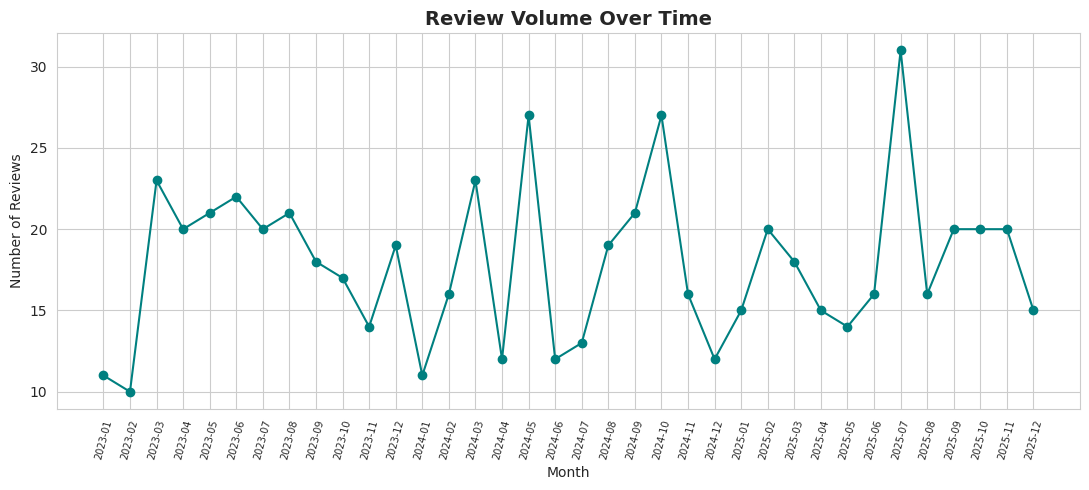

In [6]:
df_clean['review_month'] = df_clean['review_date'].dt.to_period('M')
monthly_counts = df_clean.groupby('review_month').size()
monthly_counts.index = monthly_counts.index.astype(str)

plt.figure(figsize=(11, 5))
plt.plot(monthly_counts.index, monthly_counts.values, marker='o', color='teal')
plt.title('Review Volume Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=75, fontsize=7)
plt.tight_layout()
plt.savefig('../charts/03_review_volume_over_time.png', dpi=150)
plt.show()

## 5. Visualization 4 — Cuisine vs City Heatmap

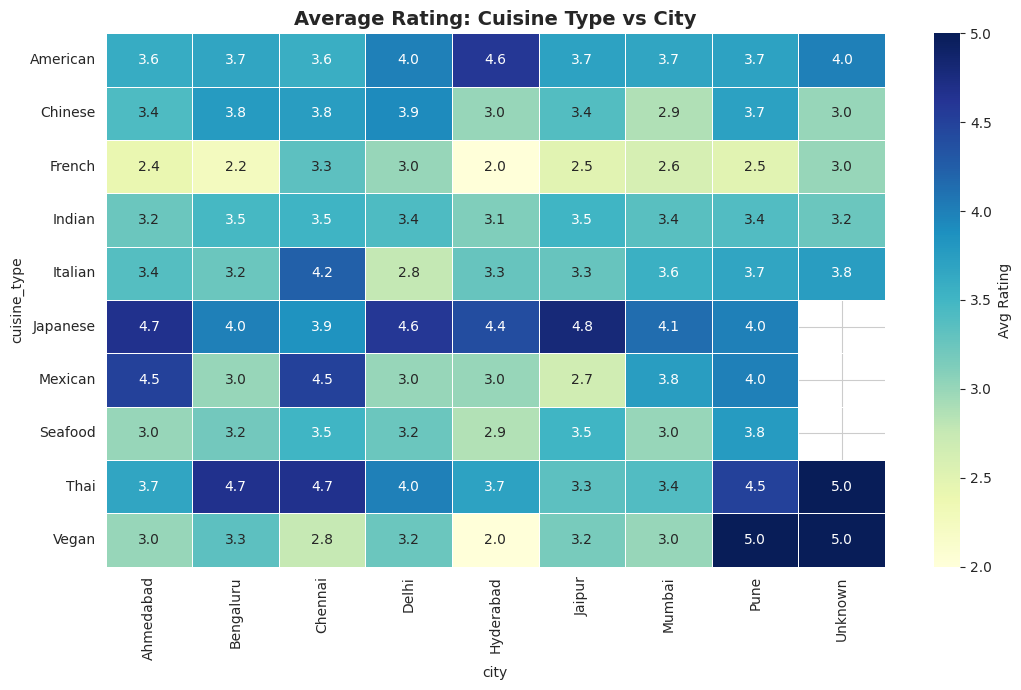

In [7]:
pivot = df_clean.pivot_table(values='rating', index='cuisine_type', columns='city', aggfunc='mean')
plt.figure(figsize=(11, 7))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlGnBu', linewidths=0.5, cbar_kws={'label': 'Avg Rating'})
plt.title('Average Rating: Cuisine Type vs City', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../charts/04_cuisine_city_heatmap.png', dpi=150)
plt.show()

## 6. Visualization 5 — Review Length by Rating

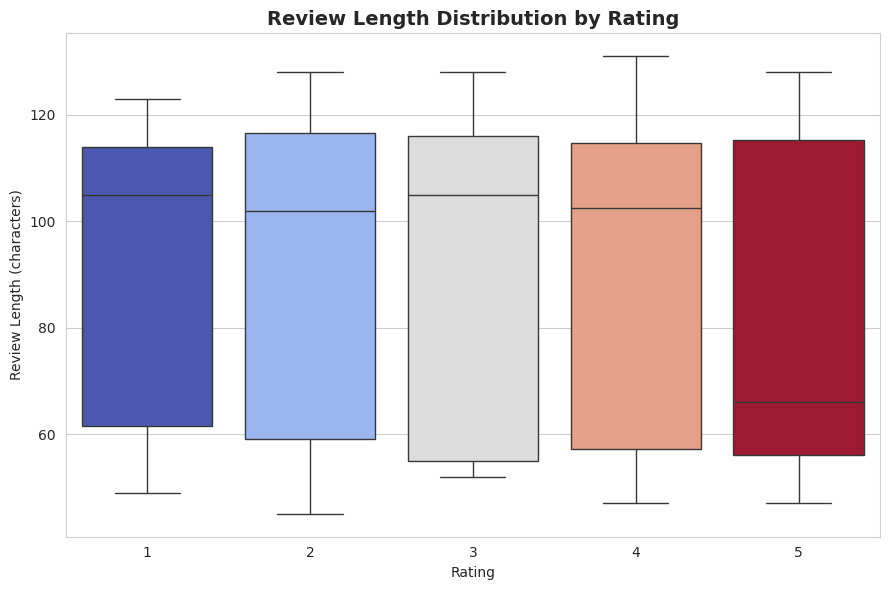

In [8]:
plt.figure(figsize=(9, 6))
sns.boxplot(data=df_clean, x='rating', y='review_length', hue='rating', palette='coolwarm', legend=False)
plt.title('Review Length Distribution by Rating', fontsize=14, fontweight='bold')
plt.xlabel('Rating')
plt.ylabel('Review Length (characters)')
plt.tight_layout()
plt.savefig('../charts/05_review_length_by_rating.png', dpi=150)
plt.show()

## 7. Visualization 6 — Word Cloud of Review Text

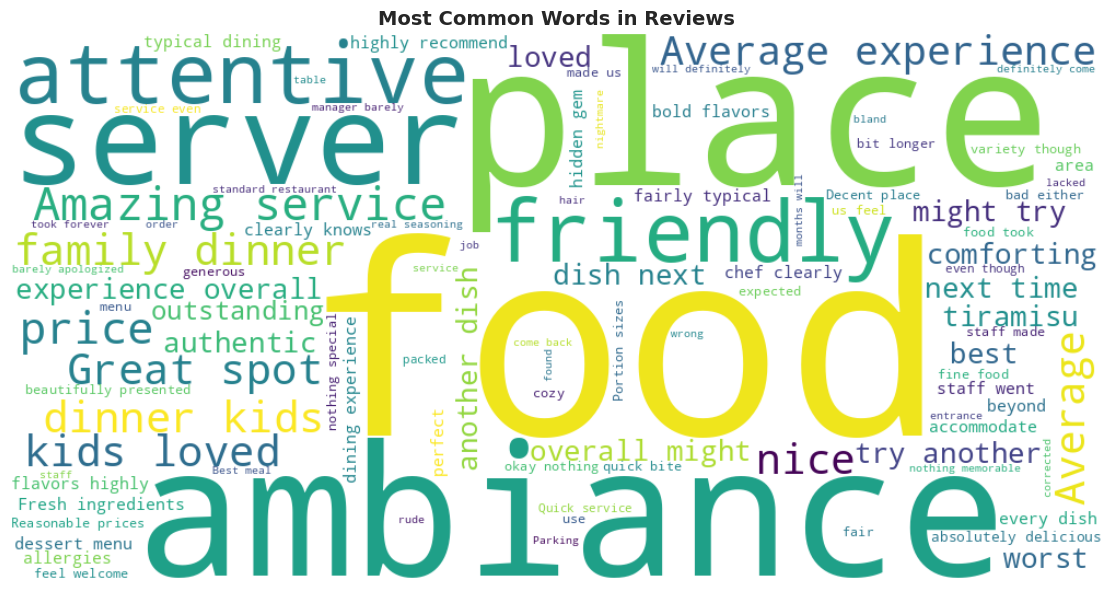

In [9]:
all_text = ' '.join(df_clean['review_text'].tolist())
wc = WordCloud(width=1000, height=500, background_color='white', colormap='viridis', max_words=100).generate(all_text)
plt.figure(figsize=(12, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Reviews', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../charts/06_wordcloud.png', dpi=150)
plt.show()

## 8. Visualization Takeaways

- Ratings cluster around 3-4 stars, with a long tail of 1-star reviews.
- Japanese and Thai cuisines lead on average rating; French trails.
- Review volume shows a steady trend across the 2023-2025 window.
- Very short and very long reviews tend to correlate with rating extremes.
- Common words in the word cloud reflect both praise ("delicious", "friendly") and complaints ("slow", "cold").

*This notebook covers Task 3 (Data Visualization) of the CodeAlpha Data Analytics Internship.*
